# Structural Alerts & GNN Explainability — Tox21 (All 12 Tasks)

Two analyses across **all 12 Tox21 tasks** (NaN labels kept, not dropped):
1. **Brenk/REOS structural alerts** — per-task alert prevalence vs toxicity label
2. **GNNExplainer + Integrated Gradients** — atom importance per task, aligned with alerts

Run on **Colab T4 GPU**.


## 1 · Mount Drive & set paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys

DRIVE_ROOT = '/content/drive/MyDrive/Research/HybridGNN/TOX'
DATA_CSV = f'{DRIVE_ROOT}/tox21_dataset.csv'
CKPT_PATH = f'{DRIVE_ROOT}/checkpoints_tox21/SR-ARE/sage_gin_gin_best/best_model_run03.pt.pt'
TASK_NAME = 'SR-ARE'

RESULTS_DIR = f'{DRIVE_ROOT}/{TASK_NAME}/results_tox21/explainability'

os.makedirs(RESULTS_DIR, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)

print('Drive mounted.')
print('Checkpoint path:', CKPT_PATH)
print('Results will go to:', RESULTS_DIR)


Drive mounted.
Checkpoint path: /content/drive/MyDrive/Research/HybridGNN/TOX/checkpoints_tox21/SR-ARE/sage_gin_gin_best/best_model_run03.pt.pt
Results will go to: /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability


## 2 · Install dependencies

In [3]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch_geometric', 'rdkit', 'captum'], check=True)
# captum provides Integrated Gradients
print('Done.')

Done.


## 3 · Imports

In [ ]:
import warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
from torch_geometric.explain import Explainer, GNNExplainer

from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdMolDescriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image
import io

from captum.attr import IntegratedGradients

from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


## 4 · Load utils.py from Drive

In [ ]:
from utils import (
    one_hot_encoding,
    get_atom_features,
    get_bond_features,
    smiles_to_graph_list,
    scaffold_split,
    get_valid_mask,
    save_ckp,
    load_ckp,
    optimizer_to,
    round_to_4,
    log_weights_to_tensorboard,
    inspect_model_weights
)

print('utils.py loaded.')

## 5 · GNN model definition
Must match the architecture of the saved checkpoint exactly.

In [ ]:
BEST_LAYER_TYPES = ['sage', 'gin', 'gin']
BEST_HIDDEN   = 520
BEST_DROPOUT = np.round(0.43479245061434324, 4)

class GNN(torch.nn.Module):
    def __init__(self, layer_types, hidden_dim, dropout):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        in_dim = 79
        for lt in layer_types:
            if lt == 'gcn':
                self.convs.append(GCNConv(in_dim, hidden_dim))
            elif lt == 'gat':
                self.convs.append(GATConv(in_dim, hidden_dim))
            elif lt == 'gin':
                mlp = nn.Sequential(
                    nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
                self.convs.append(GINConv(mlp, eps=0.00005, train_eps=True))
            elif lt == 'sage':
                self.convs.append(SAGEConv(in_dim, hidden_dim))
            in_dim = hidden_dim
        self.drop = nn.Dropout(p=dropout)
        self.out  = Linear(hidden_dim * 2, 1)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = torch.tanh(x)
        x = self.drop(x)
        x = torch.cat([gmp(x, batch), gap(x, batch)], dim=1)
        return self.out(x)

print('GNN defined.')


GNN defined.


## 6 · Load trained checkpoint

In [ ]:
KNOWN_DROPOUT = np.round(0.43479245061434324, 4)
KNOWN_LR = np.round(0.0003585966617440445, 5)
KNOWN_WD = 1e-4

In [ ]:
model = GNN(BEST_LAYER_TYPES, BEST_HIDDEN, BEST_DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=KNOWN_LR)

if os.path.exists(CKPT_PATH):
    # Replicating the functionality of load_ckp to apply the fix.
    # The UnpicklingError is resolved by setting weights_only=False in torch.load.
    device_ckp = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    try:
        checkpoint = torch.load(CKPT_PATH, map_location=device_ckp, weights_only=False)
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        # Assuming 'epoch' or 'start_epoch' key exists in the checkpoint, default to 0 if not.
        start_epoch = checkpoint.get('epoch', checkpoint.get('start_epoch', 0))
        print(f'Checkpoint loaded (trained to epoch {start_epoch})')
    except Exception as e:
        print(f'Error loading checkpoint even with weights_only=False: {e}')
        print('Please ensure the checkpoint file is compatible with this PyTorch version and setup.')
else:
    print('WARNING: checkpoint not found at', CKPT_PATH)
    print('The model will use random weights — explainability results will be meaningless.')
    print('Train the model first using the experiment notebook.')

model.eval()

The model will use random weights — explainability results will be meaningless.
Train the model first using the experiment notebook.


GNN(
  (convs): ModuleList(
    (0): SAGEConv(79, 520, aggr=mean)
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=520, out_features=520, bias=True)
      (1): BatchNorm1d(520, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=520, out_features=520, bias=True)
      (4): ReLU()
    ))
  )
  (drop): Dropout(p=0.4348, inplace=False)
  (out): Linear(in_features=1040, out_features=1, bias=True)
)

## 7 · Load dataset

In [ ]:
TASK_NAME = 'SR-ARE'

In [ ]:
GLOBAL_SEED = 43

In [ ]:
df = pd.read_csv(DATA_CSV)
task_cols = [TASK_NAME]
print(f'Total tasks ({len(task_cols)}): {task_cols}')

# 2. filter invalid SMILES while preserving multi-task label vectors (with NaNs)
X_smiles = []
y_labels = []

for idx, row in df.iterrows():
  smi = row['smiles']
  if Chem.MolFromSmiles(smi) is not None:
    X_smiles.append(smi)
    y_labels.append(row[task_cols].values.astype(float))

y_labels = np.array(y_labels)

print(f'Valid SMILES: {len(X_smiles)} / {len(df)}')
print(f'Label matrix shape: {y_labels.shape}')

# Summary of valid vs missing labels across all tasks
for col_idx, col_name in enumerate(task_cols):
  col_vals = y_labels[:, col_idx]
  valid_mask = ~np.isnan(col_vals)
  positives = np.sum(col_vals[valid_mask] == 1)
  negatives = np.sum(col_vals[valid_mask] == 0)
  missing = np.sum(~valid_mask)
  print(
      f'Task {col_name:<12} | Pos: {positives:<5} | Neg: {negatives:<5} |'
      f' Missing: {missing:<5}'
  )

Total tasks (1): ['SR-ARE']


[20:07:46] WARNING: not removing hydrogen atom without neighbors
[20:07:47] Explicit valence for atom # 8 Al, 6, is greater than permitted
[20:07:48] Explicit valence for atom # 3 Al, 6, is greater than permitted
[20:07:48] Explicit valence for atom # 4 Al, 6, is greater than permitted
[20:07:49] Explicit valence for atom # 4 Al, 6, is greater than permitted
[20:07:51] Explicit valence for atom # 9 Al, 6, is greater than permitted
[20:07:51] Explicit valence for atom # 5 Al, 6, is greater than permitted
[20:07:52] Explicit valence for atom # 16 Al, 6, is greater than permitted
[20:07:54] Explicit valence for atom # 20 Al, 6, is greater than permitted


Valid SMILES: 7823 / 7831
Label matrix shape: (7823, 1)
Task SR-ARE       | Pos: 942   | Neg: 4883  | Missing: 1998 


## 8 · Brenk & REOS Structural Alerts

These are curated lists of SMARTS patterns that flag known reactive or undesirable substructures.
- **Brenk alerts**: fragments associated with toxicity or metabolic instability
- **REOS filters**: Rapid Elimination Of Swill — flags generally problematic groups

We screen every molecule in the dataset and record which alerts fire.

Compare the number of alert-containing compounds to the number of toxic labels


In [ ]:
BRENK_ALERTS = {
    'Nitro_group':            '[N+](=O)[O-]',
    'Michael_acceptor':       'C=CC(=O)',
    'Aldehyde':               '[CX3H1](=O)',
    'Epoxide':                'C1OC1',
    'Acyl_halide':            'C(=O)[F,Cl,Br,I]',
    'Isocyanate':             'N=C=O',
    'Thiocyanate':            'SC#N',
    'Diazo':                  'N#N',
    'Peroxide':               'OO',
    'Halogenated_heterocycle':'c1ccnc(Cl)c1',
    'Heavy_metal':            '[As,Se,Hg,Pb,Cd,Tl]',
    'Alkyl_halide_reactive':  '[CX4][Cl,Br,I]',
    'Aniline':                'Nc1ccccc1',
    'Hydrazine':              'NN',
    'Hydroxamic_acid':        'C(=O)NO',
}
REOS_ALERTS = {
    'Sulfonyl_halide':   'S(=O)(=O)[Cl,F]',
    'Acid_anhydride':    'C(=O)OC(=O)',
    'Activated_ester':   'C(=O)O[N,c]',
    'Aziridine':         'C1CN1',
    'Vinyl_halide':      'C=C[Cl,Br]',
    'Phosphonate':       'P(=O)(O)O',
    'Thiol':             '[SH]',
    'Disulfide':         'SS',
}
ALL_ALERTS  = {**BRENK_ALERTS, **REOS_ALERTS}
compiled    = {name: Chem.MolFromSmarts(sma) for name, sma in ALL_ALERTS.items()}
alert_names = list(ALL_ALERTS.keys())

alert_records = []
for smi, y_vec in zip(X_smiles, y_labels):   # y_vec shape: (n_tasks,)
    mol = Chem.MolFromSmiles(smi)
    row = {'smiles': smi}
    # store each task label (may be NaN) — NaNs are kept as-is
    for t_idx, t_name in enumerate(task_cols):
        row[t_name] = y_vec[t_idx]            # float or nan
    fired = []
    for name, patt in compiled.items():
        hits = int(patt is not None and mol.HasSubstructMatch(patt))
        row[name] = hits
        if hits:
            fired.append(name)
    row['n_alerts_fired'] = len(fired)
    row['any_alert']      = int(len(fired) > 0)
    alert_records.append(row)

alert_df = pd.DataFrame(alert_records)
print(f'alert_df shape: {alert_df.shape}')
print(f'Molecules with >=1 alert: {alert_df["any_alert"].sum()} '
      f'({100*alert_df["any_alert"].mean():.1f}%)')
freq = alert_df[alert_names].sum().sort_values(ascending=False)
print('\nAlert frequency (all molecules):')
print(freq[freq > 0].to_string())


[20:07:55] WARNING: not removing hydrogen atom without neighbors


alert_df shape: (7823, 27)
Molecules with >=1 alert: 3076 (39.3%)

Alert frequency (all molecules):
Aniline                    1366
Michael_acceptor            621
Alkyl_halide_reactive       372
Nitro_group                 343
Hydrazine                   166
Aldehyde                    166
Phosphonate                 131
Activated_ester             115
Vinyl_halide                 71
Epoxide                      70
Thiol                        57
Disulfide                    51
Heavy_metal                  34
Acyl_halide                  34
Acid_anhydride               29
Halogenated_heterocycle      29
Hydroxamic_acid              26
Isocyanate                   16
Peroxide                     14
Thiocyanate                  12
Aziridine                     9
Sulfonyl_halide               8


#TODO:
How many of the alerted molecules have NaN values.

## 9 · Alert presence vs toxicity label

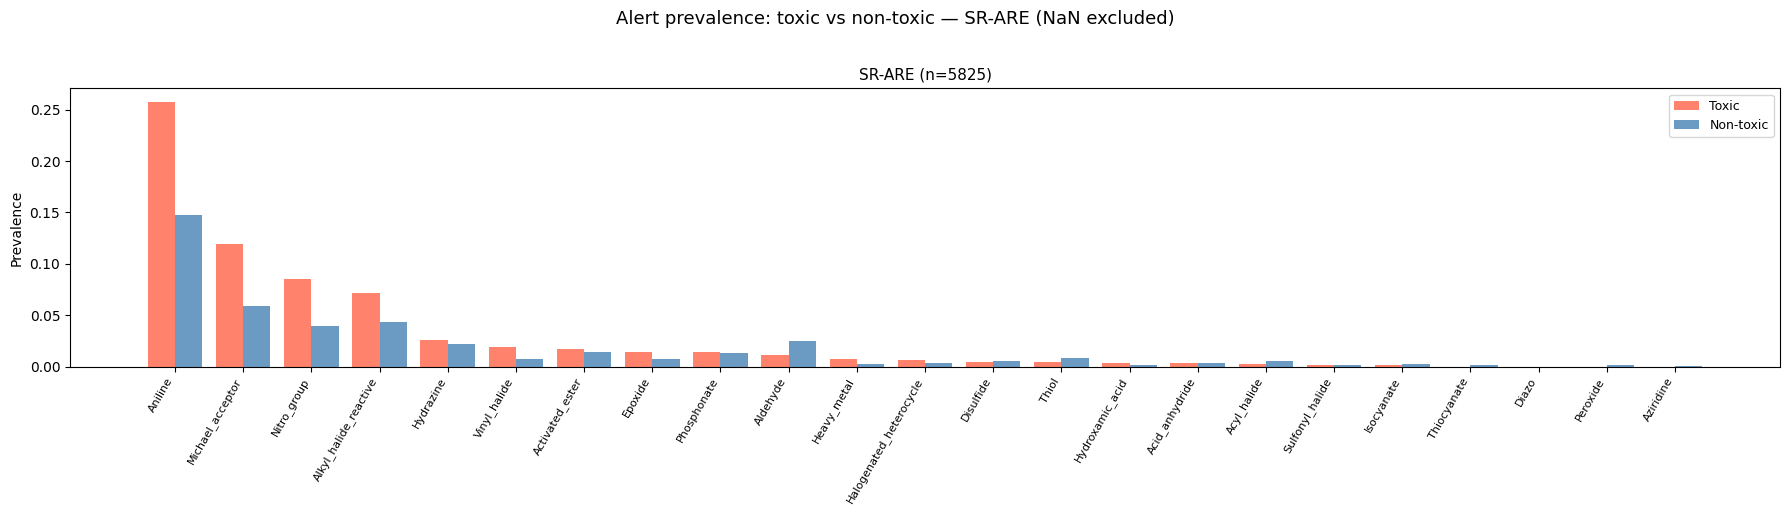

Saved to /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability/alerts_vs_toxicity_SR-ARE.pdf
Alert table saved to /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability/structural_alerts_per_molecule.csv


In [ ]:
# Alert prevalence in toxic vs non-toxic molecules for 'SR-ARE' (NaN rows skipped)
target_task = 'SR-ARE'

fig, ax = plt.subplots(figsize=(18, 5))

# Only rows where 'SR-ARE' label is known (not NaN)
task_df = alert_df[alert_df[target_task].notna()].copy()
task_df[target_task] = task_df[target_task].astype(int)

toxic_df = task_df[task_df[target_task] == 1]
nontoxic_df = task_df[task_df[target_task] == 0]

if len(toxic_df) == 0 or len(nontoxic_df) == 0:
  ax.set_title(f'{target_task}\n(insufficient data)', fontsize=10)
else:
  alert_toxic = toxic_df[alert_names].mean().sort_values(ascending=False)
  alert_nontoxic = nontoxic_df[alert_names].mean().reindex(alert_toxic.index)

  x = range(len(alert_names))
  ax.bar(
      [i - 0.2 for i in x],
      alert_toxic.values,
      width=0.4,
      label='Toxic',
      color='tomato',
      alpha=0.8,
  )
  ax.bar(
      [i + 0.2 for i in x],
      alert_nontoxic.values,
      width=0.4,
      label='Non-toxic',
      color='steelblue',
      alpha=0.8,
  )

  ax.set_xticks(list(x))
  ax.set_xticklabels(alert_toxic.index, rotation=60, ha='right', fontsize=8)
  ax.set_title(f'{target_task} (n={len(task_df)})', fontsize=11)
  ax.set_ylabel('Prevalence', fontsize=10)
  ax.legend(fontsize=9)

plt.suptitle(
    f'Alert prevalence: toxic vs non-toxic — {target_task} (NaN excluded)',
    fontsize=13,
    y=1.02,
)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, f'alerts_vs_toxicity_{target_task}.pdf')
plt.savefig(plot_path, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved to {plot_path}')

# Save full alert table (includes all task columns with NaN preserved)
csv_path = os.path.join(RESULTS_DIR, 'structural_alerts_per_molecule.csv')
alert_df.to_csv(csv_path, index=False)
print(f'Alert table saved to {csv_path}')

## 10 · GNNExplainer — atom importance masks

GNNExplainer learns a soft mask over edges (and optionally nodes) that maximally preserves
the model's prediction for a given molecule. High-mask atoms are the ones the model
"looks at" when predicting toxicity.

We run it on a sample of **toxic molecules** and check whether the top-importance atoms
belong to known structural alert substructures.


In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='raw',
    ),
)

N_EXPLAIN_PER_TASK = 3   # molecules to explain per task

# Build {task -> list of smiles labelled toxic in that task (NaN excluded)}
task_toxic_smiles = {}
for t_idx, task in enumerate(task_cols):
    candidates = [
        smi for smi, y_vec in zip(X_smiles, y_labels)
        if not np.isnan(y_vec[t_idx]) and y_vec[t_idx] == 1.0
    ]
    task_toxic_smiles[task] = candidates[:N_EXPLAIN_PER_TASK]
    print(f'{task:<15}: {len(candidates)} toxic molecules → explaining {len(task_toxic_smiles[task])}')

SR-ARE         : 942 toxic molecules → explaining 3


In [ ]:
def smiles_to_single_graph(smi):
    mol = Chem.MolFromSmiles(smi)
    n   = mol.GetNumAtoms()
    ref = Chem.MolFromSmiles('O=O')
    nf  = len(get_atom_features(ref.GetAtomWithIdx(0)))
    ef  = len(get_bond_features(ref.GetBondBetweenAtoms(0, 1)))
    X   = np.zeros((n, nf))
    for atom in mol.GetAtoms():
        X[atom.GetIdx()] = get_atom_features(atom)
    X = torch.tensor(X, dtype=torch.float)
    rows, cols = np.nonzero(GetAdjacencyMatrix(mol))
    E  = torch.stack([torch.from_numpy(rows.astype(np.int64)),
                      torch.from_numpy(cols.astype(np.int64))], dim=0)
    ne = 2 * mol.GetNumBonds()
    EF = np.zeros((ne, ef))
    for k, (i, j) in enumerate(zip(rows, cols)):
        EF[k] = get_bond_features(mol.GetBondBetweenAtoms(int(i), int(j)))
    EF = torch.tensor(EF, dtype=torch.float)
    batch = torch.zeros(n, dtype=torch.long)
    return Data(x=X, edge_index=E, edge_attr=EF, batch=batch)

def get_atom_importance(explanation):
    if explanation.node_mask is not None:
        return explanation.node_mask.sum(dim=1).cpu().numpy()
    return np.zeros(explanation.x.shape[0])

# explanations dict: {task -> [{'smiles':..., 'atom_importance':...}, ...]}
all_explanations = {}

for task, smiles_list in task_toxic_smiles.items():
    task_exps = []
    for smi in smiles_list:
        data    = smiles_to_single_graph(smi).to(device)
        exp     = explainer(data.x.float(), data.edge_index, batch=data.batch)
        atom_imp = get_atom_importance(exp)
        task_exps.append({'smiles': smi, 'atom_importance': atom_imp})
    all_explanations[task] = task_exps
    print(f'GNNExplainer done: {task} ({len(task_exps)} molecules)')

# Flat list for backward compatibility with visualisation cells
explanations = [e for exps in all_explanations.values() for e in exps]
print(f'\nTotal explained: {len(explanations)} molecules across {len(task_cols)} tasks')


GNNExplainer done: SR-ARE (3 molecules)

Total explained: 3 molecules across 1 tasks


## 11 · Visualise atom importance on molecule structures

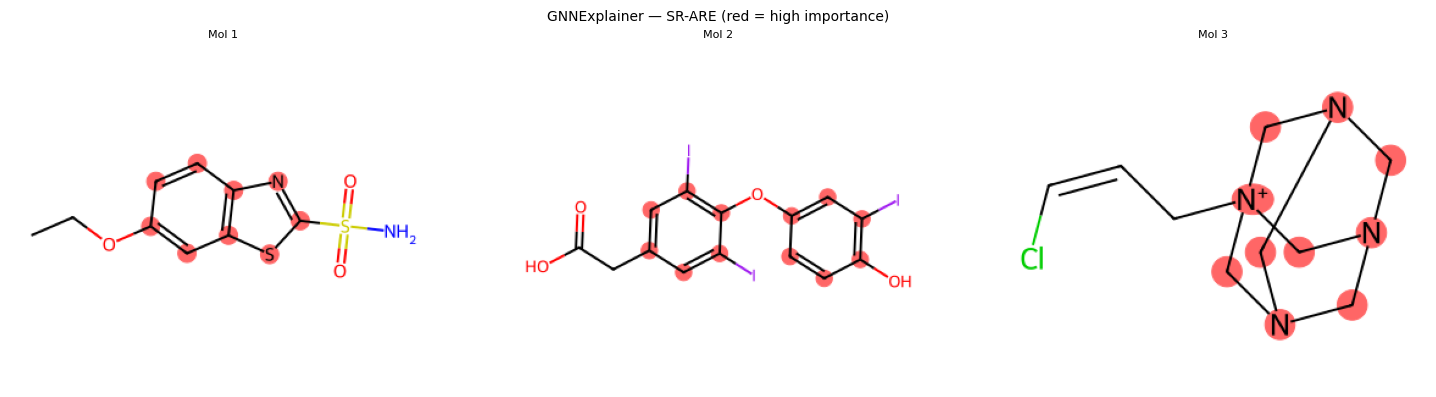

Saved: /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability/gnnexplainer_SR_ARE.png


In [ ]:
from rdkit.Chem import Draw, AllChem

for task, task_exps in all_explanations.items():
    if not task_exps:
        continue
    n_mols = len(task_exps)
    fig, axes = plt.subplots(1, n_mols, figsize=(5 * n_mols, 4))
    if n_mols == 1:
        axes = [axes]
    for idx, (exp_data, ax) in enumerate(zip(task_exps, axes)):
        smi = exp_data['smiles']
        imp = exp_data['atom_importance']
        mol = Chem.MolFromSmiles(smi)
        AllChem.Compute2DCoords(mol)
        imp_norm        = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
        highlight_atoms = [i for i, v in enumerate(imp_norm) if v > 0.5]
        img = Draw.MolToImage(mol, size=(350, 280),
                              highlightAtoms=highlight_atoms,
                              highlightColor=(1.0, 0.4, 0.4))
        ax.imshow(img)
        ax.set_title(f'Mol {idx+1}', fontsize=8)
        ax.axis('off')
    plt.suptitle(f'GNNExplainer — {task} (red = high importance)', fontsize=10)
    plt.tight_layout()
    task_safe = task.replace('-', '_')
    plot_path = os.path.join(RESULTS_DIR, f'gnnexplainer_{task_safe}.png')
    plt.savefig(plot_path,format = 'pdf', dpi=120)
    plt.show()
    print(f'Saved: {plot_path}')

## 12 · Alert alignment analysis

For each explained molecule, check whether the **top-importance atoms** (from GNNExplainer)
overlap with atoms that belong to known structural alert substructures.

A high overlap means the model has implicitly learned to focus on chemically meaningful
reactive groups — strong evidence of interpretability.


In [ ]:
def get_alert_atom_indices(smi):
    # Disable automatic reordering if using non-canonical SMILES strings
    params = Chem.SmilesParserParams()
    params.sanitize = True
    params.removeHs = False  # Ensure H handling matches graph processing logic
    mol = Chem.MolFromSmiles(smi, params)
    if mol is None:
        return {}

    fired = {}
    for name, patt in compiled.items():
        if patt is not None and mol.HasSubstructMatch(patt):
            matches = mol.GetSubstructMatches(patt)
            atom_idxs = set(idx for match in matches for idx in match)
            fired[name] = atom_idxs
    return fired

alignment_results = []
for task, task_exps in all_explanations.items():
    for exp_data in task_exps:
        smi      = exp_data['smiles']
        imp      = exp_data['atom_importance']
        imp_norm = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
        top_atoms       = set(np.where(imp_norm > 0.5)[0])
        alert_atoms     = get_alert_atom_indices(smi)
        all_alert_atoms = set(idx for s in alert_atoms.values() for idx in s)
        if len(top_atoms) == 0 or len(all_alert_atoms) == 0:
            overlap = 0.0
        else:
            overlap = len(top_atoms & all_alert_atoms) / len(top_atoms | all_alert_atoms)
        alignment_results.append({
            'task':            task,
            'smiles':          smi,
            'alerts_fired':    list(alert_atoms.keys()),
            'n_top_atoms':     len(top_atoms),
            'n_alert_atoms':   len(all_alert_atoms),
            'overlap_jaccard': round(overlap, 4),
        })

align_df = pd.DataFrame(alignment_results)
print('Per-task mean Jaccard overlap (GNNExplainer vs alert atoms):')
print(align_df.groupby('task')['overlap_jaccard'].mean().round(3).to_string())
print(f'\nOverall mean: {align_df["overlap_jaccard"].mean():.3f}')
align_df.to_csv(os.path.join(RESULTS_DIR, 'gnnexplainer_alert_alignment_all_tasks.csv'), index=False)

Per-task mean Jaccard overlap (GNNExplainer vs alert atoms):
task
SR-ARE    0.0

Overall mean: 0.000


## 13 · Integrated Gradients (Captum)

Integrated Gradients is a gradient-based attribution method that attributes the model's
output to each **input feature** (atom feature dimensions) by integrating gradients along
a path from a baseline (zero features) to the actual input.

This gives a finer-grained view than GNNExplainer: instead of one importance score per atom,
you get one score per atom **per feature dimension** — so you can see which chemical
properties (aromaticity, hybridisation, etc.) drive the prediction.


In [ ]:
class GNNForIG(torch.nn.Module):
    def __init__(self, gnn):
        super().__init__()
        self.gnn = gnn

    def forward(self, x, edge_index, batch):
        original_num_nodes = batch.size(0)
        n_steps = x.shape[0] // original_num_nodes if original_num_nodes > 0 else 1
        if edge_index.numel() > 0:
            offset = torch.arange(n_steps, device=x.device) * original_num_nodes
            rep_ei = edge_index.unsqueeze(0).repeat(n_steps, 1, 1)
            rep_ei = rep_ei + offset.unsqueeze(1).unsqueeze(2)
            rep_ei = rep_ei.view(2, -1)
        else:
            rep_ei = torch.empty((2, 0), dtype=torch.long, device=x.device)
        rep_batch = torch.arange(n_steps, device=x.device).repeat_interleave(original_num_nodes)
        return torch.sigmoid(self.gnn(x, rep_ei, rep_batch))


def run_integrated_gradients(model, data, n_steps=50):
    model.eval()
    x          = data.x.float().to(device).requires_grad_(True)
    edge_index = data.edge_index.to(device)
    batch      = data.batch.to(device)
    wrapper    = GNNForIG(model).to(device)
    ig         = IntegratedGradients(wrapper)
    baseline   = torch.zeros_like(x)
    attributions, delta = ig.attribute(
        inputs=x, baselines=baseline, target=None,
        n_steps=n_steps, return_convergence_delta=True,
        additional_forward_args=(edge_index, batch)
    )
    return attributions.abs().sum(dim=1).detach().cpu().numpy(), float(delta.mean().abs())


# Run IG for every explained molecule across all tasks
all_ig_results = {}

for task, task_exps in all_explanations.items():
    task_ig = []
    for exp_data in task_exps:
        smi  = exp_data['smiles']
        data = smiles_to_single_graph(smi).to(device)
        attr, delta = run_integrated_gradients(model, data)
        task_ig.append({'smiles': smi, 'atom_attr': attr, 'convergence_delta': delta})
        print(f'  [{task}] IG done | δ={delta:.4f} | {smi[:35]}')
    all_ig_results[task] = task_ig

# Flat list for comparison cell
ig_results = [r for rs in all_ig_results.values() for r in rs]
print(f'\nIG complete: {len(ig_results)} molecules')


  [SR-ARE] IG done | δ=0.0044 | CCOc1ccc2nc(S(N)(=O)=O)sc2c1
  [SR-ARE] IG done | δ=0.0022 | O=C(O)Cc1cc(I)c(Oc2ccc(O)c(I)c2)c(I
  [SR-ARE] IG done | δ=0.0115 | Cl/C=C\C[N+]12CN3CN(CN(C3)C1)C2

IG complete: 3 molecules


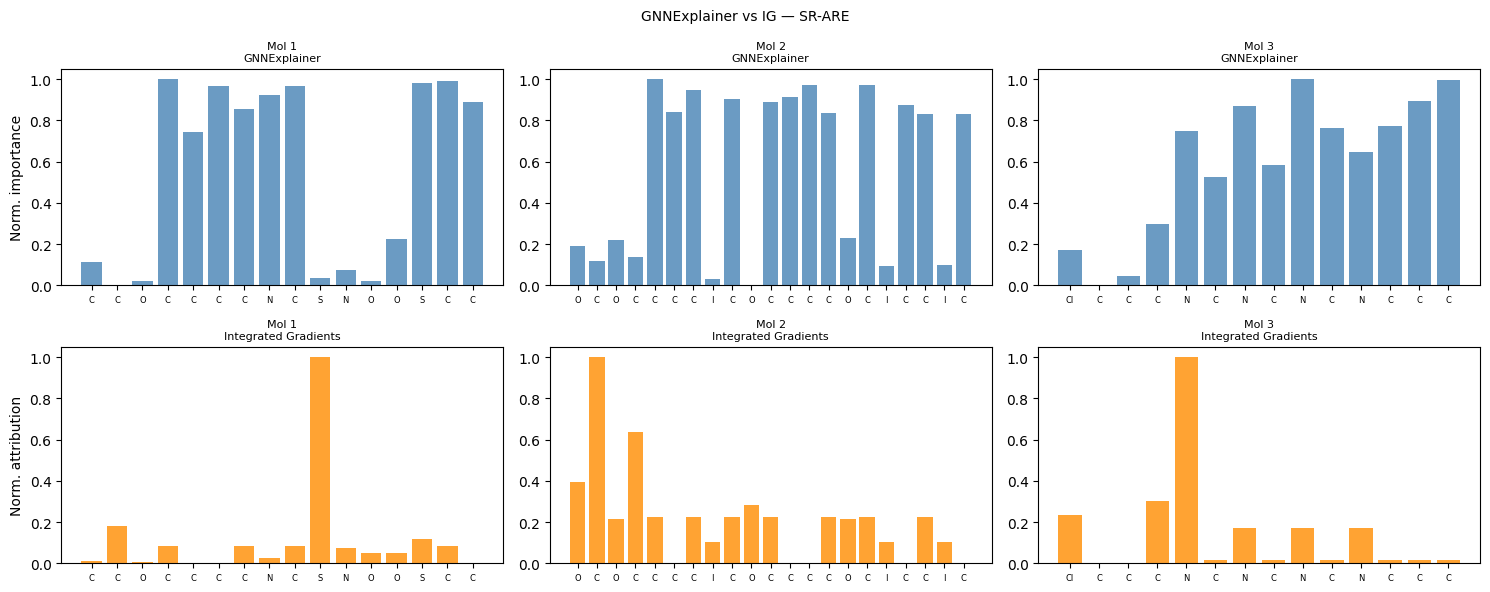

Saved: /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability/gnnexplainer_vs_ig_SR_ARE.png


In [ ]:
for task in task_cols:
    task_exps = all_explanations.get(task, [])
    task_ig   = all_ig_results.get(task,   [])
    if not task_exps:
        continue
    n_mols = len(task_exps)
    fig, axes = plt.subplots(2, n_mols, figsize=(5 * n_mols, 6))
    if n_mols == 1:
        axes = axes.reshape(2, 1)
    for idx in range(n_mols):
        smi    = task_exps[idx]['smiles']
        mol    = Chem.MolFromSmiles(smi)
        syms   = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms())]
        n      = len(syms)
        gnn_imp = task_exps[idx]['atom_importance']
        ig_imp  = task_ig[idx]['atom_attr'] if idx < len(task_ig) else np.zeros(n)
        gnn_n   = (gnn_imp - gnn_imp.min()) / (gnn_imp.max() - gnn_imp.min() + 1e-8)
        ig_n    = (ig_imp  - ig_imp.min())  / (ig_imp.max()  - ig_imp.min()  + 1e-8)
        axes[0, idx].bar(range(n), gnn_n, color='steelblue', alpha=0.8)
        axes[0, idx].set_title(f'Mol {idx+1}\nGNNExplainer', fontsize=8)
        axes[0, idx].set_xticks(range(n))
        axes[0, idx].set_xticklabels(syms, fontsize=6)
        axes[1, idx].bar(range(n), ig_n,  color='darkorange', alpha=0.8)
        axes[1, idx].set_title(f'Mol {idx+1}\nIntegrated Gradients', fontsize=8)
        axes[1, idx].set_xticks(range(n))
        axes[1, idx].set_xticklabels(syms, fontsize=6)
    axes[0, 0].set_ylabel('Norm. importance')
    axes[1, 0].set_ylabel('Norm. attribution')
    plt.suptitle(f'GNNExplainer vs IG — {task}', fontsize=10)
    plt.tight_layout()
    task_safe = task.replace('-', '_')
    plot_path = os.path.join(RESULTS_DIR, f'gnnexplainer_vs_ig_{task_safe}.png')
    plt.savefig(plot_path, dpi=120)
    plt.show()
    print(f'Saved: {plot_path}')


## 14 · Summary & interpretation

In [ ]:
print('='*60)
print('STRUCTURAL ALERTS SUMMARY — ALL TASKS')
print('='*60)
print(f'Total molecules screened : {len(alert_df)}')
print(f'With >=1 alert           : {alert_df["any_alert"].sum()} '
      f'({100*alert_df["any_alert"].mean():.1f}%)')
print('\nTop 5 alerts by frequency:')
print(freq.head(5).to_string())
print()
print('='*60)
print('GNNExplainer ALERT ALIGNMENT — PER TASK')
print('='*60)
per_task = align_df.groupby('task')['overlap_jaccard'].agg(['mean','std','count'])
per_task.columns = ['mean_jaccard', 'std_jaccard', 'n_molecules']
print(per_task.round(3).to_string())
print(f'\nOverall mean Jaccard: {align_df["overlap_jaccard"].mean():.3f}')
print()
print('Interpretation:')
print('  > 0.5  → model focuses on known reactive fragments')
print('  0.2-0.5 → partial alignment')
print('  < 0.2  → model uses features independent of known alerts')
print()
print('All outputs saved to:', RESULTS_DIR)


STRUCTURAL ALERTS SUMMARY — ALL TASKS
Total molecules screened : 7823
With >=1 alert           : 3076 (39.3%)

Top 5 alerts by frequency:
Aniline                  1366
Michael_acceptor          621
Alkyl_halide_reactive     372
Nitro_group               343
Hydrazine                 166

GNNExplainer ALERT ALIGNMENT — PER TASK
        mean_jaccard  std_jaccard  n_molecules
task                                          
SR-ARE           0.0          0.0            3

Overall mean Jaccard: 0.000

Interpretation:
  > 0.5  → model focuses on known reactive fragments
  0.2-0.5 → partial alignment
  < 0.2  → model uses features independent of known alerts

All outputs saved to: /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability


In [ ]:
alignment_results = []
for task, task_exps in all_explanations.items():
  for exp_data in task_exps:
    smi = exp_data['smiles']
    imp = exp_data['atom_importance']

    # Min-max normalization of atom importances
    imp_norm = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
    top_atoms = set(np.where(imp_norm > 0.5)[0])

    alert_atoms = get_alert_atom_indices(smi)
    all_alert_atoms = set(idx for s in alert_atoms.values() for idx in s)

    intersection = top_atoms & all_alert_atoms
    union = top_atoms | all_alert_atoms

    # Compute metrics safely handling zero denominators
    jaccard = (
        len(intersection) / len(union) if len(union) > 0 else 0.0
    )
    recall = (
        len(intersection) / len(all_alert_atoms)
        if len(all_alert_atoms) > 0
        else 0.0
    )
    precision = (
        len(intersection) / len(top_atoms) if len(top_atoms) > 0 else 0.0
    )

    alignment_results.append({
        'task': task,
        'smiles': smi,
        'alerts_fired': list(alert_atoms.keys()),
        'n_top_atoms': len(top_atoms),
        'n_alert_atoms': len(all_alert_atoms),
        'n_intersection': len(intersection),
        'overlap_jaccard': round(jaccard, 4),
        'recall': round(recall, 4),
        'precision': round(precision, 4),
        'no_alerts_fired': len(all_alert_atoms) == 0,
        'no_top_atoms': len(top_atoms) == 0,
    })

align_df = pd.DataFrame(alignment_results)

# Filter for valid comparisons (where alerts actually exist in the molecule)
valid_df = align_df[~align_df['no_alerts_fired']]

print(
    '--- Alignment Metrics Summary (Only molecules with active alerts) ---'
)
summary = valid_df.groupby('task')[
    ['overlap_jaccard', 'recall', 'precision']
].mean().round(3)
print(summary.to_string())

print('\n--- Overall Means ---')
print(
    f'Jaccard:   {valid_df["overlap_jaccard"].mean():.3f} (all: {align_df["overlap_jaccard"].mean():.3f})'
)
print(
    f'Recall:    {valid_df["recall"].mean():.3f} (all: {align_df["recall"].mean():.3f})'
)
print(
    f'Precision: {valid_df["precision"].mean():.3f} (all: {align_df["precision"].mean():.3f})'
)

# Save results
csv_path = os.path.join(
    RESULTS_DIR, 'gnnexplainer_alert_alignment_all_tasks.csv'
)
align_df.to_csv(csv_path, index=False)
print(f'\nAlignment table saved to {csv_path}')

--- Alignment Metrics Summary (Only molecules with active alerts) ---
        overlap_jaccard  recall  precision
task                                      
SR-ARE              0.0     0.0        0.0

--- Overall Means ---
Jaccard:   0.000 (all: 0.000)
Recall:    0.000 (all: 0.000)
Precision: 0.000 (all: 0.000)

Alignment table saved to /content/drive/MyDrive/Research/HybridGNN/TOX/SR-ARE/results_tox21/explainability/gnnexplainer_alert_alignment_all_tasks.csv
